# Benchmark : TFIDFVectorizer (ifri-mini-ml-lib) vs scikit-learn

Ce notebook compare les performances du `TFIDFVectorizer` de **ifri-mini-ml-lib** avec le module équivalent de **scikit-learn** sur les critères suivants :

- ⏱️ **Temps d'exécution** 
- 🧠 **Mémoire** 
- 📈 **Scalabilité**
- ✅ **Qualité des résultats**
- 🛡️ **Robustesse / Gestion des erreurs**

## 1. Imports

In [3]:
import sys
import os
sys.path.insert(0, os.path.abspath("../.."))

In [6]:
import time
import sys
import os
import math
import tracemalloc
import pandas as pd
import matplotlib.pyplot as plt

# Remonter à la racine du projet pour importer ifri-mini-ml-lib
sys.path.insert(0, os.path.abspath("../.."))

from ifri_mini_ml_lib.preprocessing.text.tf_idf import TFIDFVectorizer
from ifri_mini_ml_lib.preprocessing.preparation.tokenization import Tokenizer
from sklearn.feature_extraction.text import TfidfVectorizer

print("✅ Imports réussis !")

✅ Imports réussis !


## 2. Chargement du dataset

In [7]:
df = pd.read_csv("spam.csv")

print(f"✅ Dataset chargé : {len(df)} documents")
print(f"Colonnes : {df.columns.tolist()}")
print(f"Distribution : \n{df['Category'].value_counts()}")
print("\nAperçu :")
for i, row in df.head(5).iterrows():
    print(f"  [{i+1}] [{row['Category']}] {row['Message'][:60]}...")

✅ Dataset chargé : 5572 documents
Colonnes : ['Category', 'Message']
Distribution : 
Category
ham     4825
spam     747
Name: count, dtype: int64

Aperçu :
  [1] [ham] Go until jurong point, crazy.. Available only in bugis n gre...
  [2] [ham] Ok lar... Joking wif u oni......
  [3] [spam] Free entry in 2 a wkly comp to win FA Cup final tkts 21st Ma...
  [4] [ham] U dun say so early hor... U c already then say......
  [5] [ham] Nah I don't think he goes to usf, he lives around here thoug...


## 3. Préparation du corpus

In [8]:
# Tokenisation avec notre Tokenizer
tokenizer = Tokenizer()
messages_raw = df["Message"].tolist()

# Corpus tokenisé pour notre TFIDFVectorizer
corpus_tokenized = tokenizer.tokenize_corpus(messages_raw)

# Corpus brut pour sklearn (il tokenise lui-même)
corpus_raw = messages_raw

print(f"✅ Corpus préparé : {len(corpus_tokenized)} documents tokenisés")
print(f"\nExemple doc[0] tokenisé :")
print(corpus_tokenized[0][:15], "...")

✅ Corpus préparé : 5572 documents tokenisés

Exemple doc[0] tokenisé :
['go', 'until', 'jurong', 'point', 'crazy', 'available', 'only', 'in', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet'] ...


## 4. BENCHMARK 1 — Temps d'exécution ⏱️

On mesure séparément `fit()`, `transform()` et `fit_transform()` pour les deux implémentations.

In [9]:
N_RUNS = 5  # Nombre de répétitions pour moyenner les temps

# ── ifri-mini-ml-lib ──────────────────────────────────────
times_ifri = {"fit": [], "transform": [], "fit_transform": []}

for _ in range(N_RUNS):
    tfidf_ifri = TFIDFVectorizer()

    # fit()
    start = time.perf_counter()
    tfidf_ifri.fit(corpus_tokenized)
    times_ifri["fit"].append(time.perf_counter() - start)

    # transform()
    start = time.perf_counter()
    tfidf_ifri.transform(corpus_tokenized)
    times_ifri["transform"].append(time.perf_counter() - start)

    # fit_transform()
    tfidf_ifri2 = TFIDFVectorizer()
    start = time.perf_counter()
    tfidf_ifri2.fit_transform(corpus_tokenized)
    times_ifri["fit_transform"].append(time.perf_counter() - start)

# ── scikit-learn ───────────────────────────────────────────
times_sklearn = {"fit": [], "transform": [], "fit_transform": []}

for _ in range(N_RUNS):
    tfidf_sk = TfidfVectorizer()

    # fit()
    start = time.perf_counter()
    tfidf_sk.fit(corpus_raw)
    times_sklearn["fit"].append(time.perf_counter() - start)

    # transform()
    start = time.perf_counter()
    tfidf_sk.transform(corpus_raw)
    times_sklearn["transform"].append(time.perf_counter() - start)

    # fit_transform()
    tfidf_sk2 = TfidfVectorizer()
    start = time.perf_counter()
    tfidf_sk2.fit_transform(corpus_raw)
    times_sklearn["fit_transform"].append(time.perf_counter() - start)

# ── Résultats ──────────────────────────────────────────────
print("⏱️  Temps d'exécution moyen sur", N_RUNS, "runs")
print(f"{'Opération':<20} {'ifri-mini-ml-lib':>20} {'scikit-learn':>15} {'Ratio':>10}")
print("-" * 70)
for op in ["fit", "transform", "fit_transform"]:
    t_ifri  = sum(times_ifri[op])   / N_RUNS * 1000
    t_sk    = sum(times_sklearn[op]) / N_RUNS * 1000
    ratio   = t_ifri / t_sk if t_sk > 0 else float("inf")
    winner  = "✅ ifri" if t_ifri < t_sk else "✅ sklearn"
    print(f"{op:<20} {t_ifri:>17.4f} ms {t_sk:>12.4f} ms {ratio:>8.2f}x  {winner}")

⏱️  Temps d'exécution moyen sur 5 runs
Opération                ifri-mini-ml-lib    scikit-learn      Ratio
----------------------------------------------------------------------
fit                            22.7582 ms      47.6588 ms     0.48x  ✅ ifri
transform                    3591.5636 ms      36.4231 ms    98.61x  ✅ sklearn
fit_transform                3748.0614 ms      46.3960 ms    80.78x  ✅ sklearn


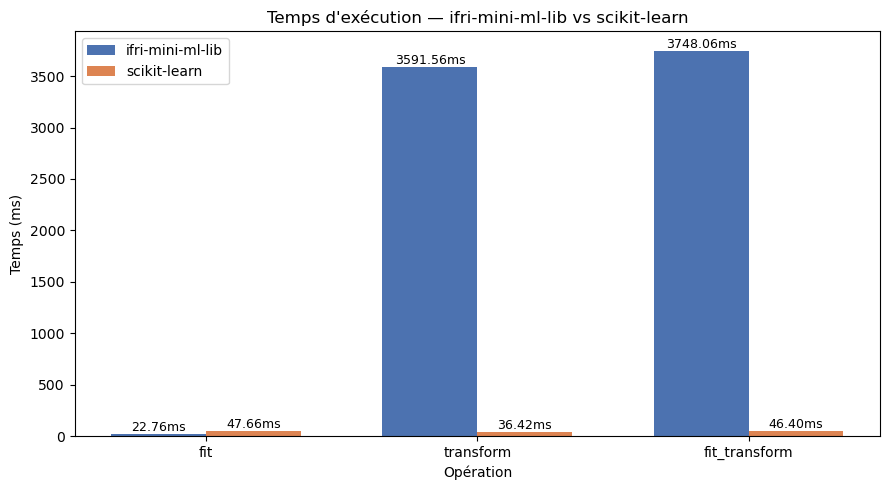

In [10]:
# Visualisation — Temps d'exécution
operations = ["fit", "transform", "fit_transform"]
t_ifri_ms   = [sum(times_ifri[op])   / N_RUNS * 1000 for op in operations]
t_sklearn_ms = [sum(times_sklearn[op]) / N_RUNS * 1000 for op in operations]

x = range(len(operations))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([i - width/2 for i in x], t_ifri_ms,   width, label="ifri-mini-ml-lib", color="#4C72B0")
bars2 = ax.bar([i + width/2 for i in x], t_sklearn_ms, width, label="scikit-learn",     color="#DD8452")

ax.set_xlabel("Opération")
ax.set_ylabel("Temps (ms)")
ax.set_title("Temps d'exécution — ifri-mini-ml-lib vs scikit-learn")
ax.set_xticks(list(x))
ax.set_xticklabels(operations)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height():.2f}ms", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height():.2f}ms", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 5. BENCHMARK 2 — Mémoire 🧠

On mesure la mémoire allouée pendant `fit_transform()` avec `tracemalloc`.

In [11]:
# ── ifri-mini-ml-lib ──────────────────────────────────────
tracemalloc.start()
tfidf_ifri_mem = TFIDFVectorizer()
matrix_ifri = tfidf_ifri_mem.fit_transform(corpus_tokenized)
_, peak_ifri = tracemalloc.get_traced_memory()
tracemalloc.stop()

# ── scikit-learn ───────────────────────────────────────────
tracemalloc.start()
tfidf_sk_mem = TfidfVectorizer()
matrix_sk = tfidf_sk_mem.fit_transform(corpus_raw)
_, peak_sklearn = tracemalloc.get_traced_memory()
tracemalloc.stop()

# ── Taille des objets en mémoire ──────────────────────────
size_vocab_ifri   = sys.getsizeof(tfidf_ifri_mem.vocabulary_)
size_vocab_sk     = sys.getsizeof(tfidf_sk_mem.vocabulary_)
size_matrix_ifri  = sys.getsizeof(matrix_ifri)
size_matrix_sk    = sys.getsizeof(matrix_sk)

print("🧠 Mémoire")
print(f"{'Mesure':<30} {'ifri-mini-ml-lib':>20} {'scikit-learn':>15}")
print("-" * 70)
print(f"{'Pic mémoire (fit_transform)':<30} {peak_ifri/1024:>17.2f} KB {peak_sklearn/1024:>12.2f} KB")
print(f"{'Taille vocabulary_':<30} {size_vocab_ifri/1024:>17.2f} KB {size_vocab_sk/1024:>12.2f} KB")
print(f"{'Taille matrice output':<30} {size_matrix_ifri/1024:>17.2f} KB {size_matrix_sk/1024:>12.2f} KB")
print(f"{'Nb termes vocabulaire':<30} {len(tfidf_ifri_mem.vocabulary_):>20} {len(tfidf_sk_mem.vocabulary_):>15}")

winner = "✅ ifri-mini-ml-lib" if peak_ifri < peak_sklearn else "✅ scikit-learn"
print(f"\n→ Moins de mémoire : {winner}")

🧠 Mémoire
Mesure                             ifri-mini-ml-lib    scikit-learn
----------------------------------------------------------------------
Pic mémoire (fit_transform)           1937571.05 KB      3383.10 KB
Taille vocabulary_                        202.75 KB       202.75 KB
Taille matrice output                      46.05 KB         0.05 KB
Nb termes vocabulaire                          8747            8709

→ Moins de mémoire : ✅ scikit-learn


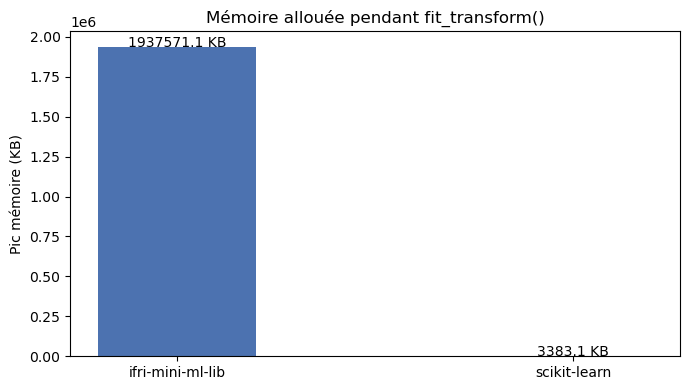

In [12]:
# Visualisation — Mémoire
labels  = ["ifri-mini-ml-lib", "scikit-learn"]
peaks   = [peak_ifri / 1024, peak_sklearn / 1024]
colors  = ["#4C72B0", "#DD8452"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, peaks, color=colors, width=0.4)
ax.set_ylabel("Pic mémoire (KB)")
ax.set_title("Mémoire allouée pendant fit_transform()")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{bar.get_height():.1f} KB", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 6. BENCHMARK 3 — Scalabilité 📈

On teste les deux implémentations sur des corpus de tailles croissantes.

In [13]:
sizes = [100, 500, 1000, 2000, 3000, 5000]
times_ifri_scale    = []
times_sklearn_scale = []

for size in sizes:
    # Sous-corpus de taille `size`
    sub_tokenized = corpus_tokenized[:size]
    sub_raw       = corpus_raw[:size]

    # ifri-mini-ml-lib
    start = time.perf_counter()
    TFIDFVectorizer().fit_transform(sub_tokenized)
    times_ifri_scale.append((time.perf_counter() - start) * 1000)

    # scikit-learn
    start = time.perf_counter()
    TfidfVectorizer().fit_transform(sub_raw)
    times_sklearn_scale.append((time.perf_counter() - start) * 1000)

print("📈 Scalabilité — fit_transform()")
print(f"{'Taille':<10} {'ifri-mini-ml-lib':>20} {'scikit-learn':>15}")
print("-" * 50)
for i, size in enumerate(sizes):
    print(f"{size:<10} {times_ifri_scale[i]:>17.2f} ms {times_sklearn_scale[i]:>12.2f} ms")

📈 Scalabilité — fit_transform()
Taille         ifri-mini-ml-lib    scikit-learn
--------------------------------------------------
100                     8.52 ms         2.91 ms
500                    73.68 ms         9.05 ms
1000                  294.22 ms        10.11 ms
2000                  680.72 ms        16.61 ms
3000                 1225.00 ms        70.96 ms
5000                 2794.91 ms        38.75 ms


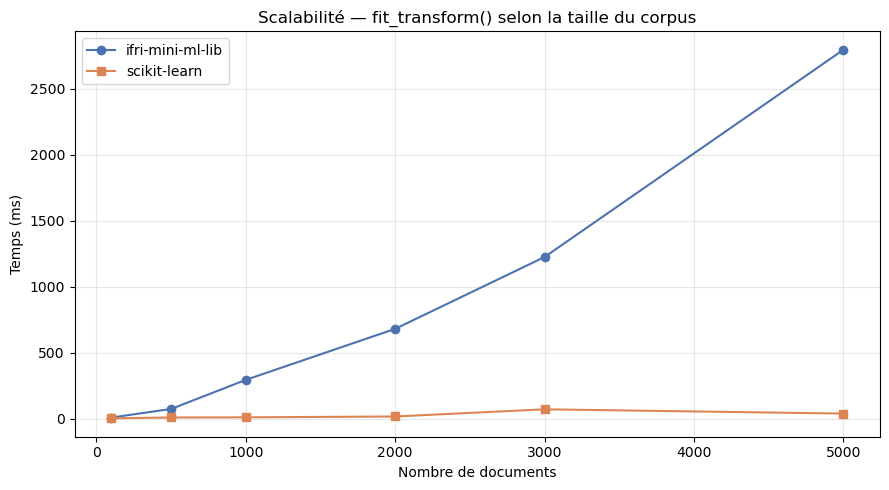

In [14]:
# Visualisation — Scalabilité
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sizes, times_ifri_scale,    marker="o", label="ifri-mini-ml-lib", color="#4C72B0")
ax.plot(sizes, times_sklearn_scale, marker="s", label="scikit-learn",     color="#DD8452")
ax.set_xlabel("Nombre de documents")
ax.set_ylabel("Temps (ms)")
ax.set_title("Scalabilité — fit_transform() selon la taille du corpus")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. BENCHMARK 4 — Qualité des résultats ✅

On vérifie que notre implémentation produit les mêmes scores que sklearn.

In [15]:
# Corpus de référence simple pour comparer terme à terme
corpus_ref_tokenized = corpus_tokenized[:100]
corpus_ref_raw       = corpus_raw[:100]

# Notre implémentation
tfidf_ifri_q = TFIDFVectorizer()
matrix_ifri_q = tfidf_ifri_q.fit_transform(corpus_ref_tokenized)

# sklearn — même tokenisation
tfidf_sk_q = TfidfVectorizer(
    lowercase=False,
    tokenizer=lambda x: x,
    preprocessor=lambda x: x
)
matrix_sk_q = tfidf_sk_q.fit_transform(corpus_ref_tokenized).toarray()

# Calcul de l'écart
delta = max(
    abs(matrix_sk_q[i][j] - matrix_ifri_q[i][j])
    for i in range(len(matrix_ifri_q))
    for j in range(len(matrix_ifri_q[i]))
)

print("✅ Qualité des résultats")
print(f"Écart max absolu vs sklearn : {delta:.8f}")
if delta < 1e-6:
    print("✅ Résultats identiques à sklearn (écart < 1e-6)")
else:
    print(f"⚠️  Écart détecté : {delta:.8f}")

✅ Qualité des résultats
Écart max absolu vs sklearn : 0.00000000
✅ Résultats identiques à sklearn (écart < 1e-6)


/home/stj/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


## 8. BENCHMARK 5 — Robustesse 🛡️

On teste les cas limites : document vide, mot inconnu, corpus minimal.

In [18]:
tfidf_rob = TFIDFVectorizer()
corpus_train = [["chat", "mange", "poisson"], ["chien", "court", "vite"]]
tfidf_rob.fit(corpus_train)

print("🛡️  Robustesse / Gestion des cas limites")
print("-" * 50)

# Test 1 — document vide
try:
    result = tfidf_rob.transform([[]])
    print(f"✅ Doc vide          → vecteur de zéros : {result}")
except Exception as e:
    print(f"❌ Doc vide          → ERREUR : {e}")

# Test 2 — mot inconnu dans transform
try:
    result = tfidf_rob.transform([["dragon", "magie"]])
    print(f"✅ Mot inconnu       → ignoré proprement, vecteur : {result}")
except Exception as e:
    print(f"❌ Mot inconnu       → ERREUR : {e}")

# Test 3 — corpus d'un seul document
try:
    tfidf_single = TFIDFVectorizer()
    result = tfidf_single.fit_transform([["chat", "mange"]])
    print(f"✅ Corpus 1 doc      → OK : {[[round(x,3) for x in row] for row in result]}")
except Exception as e:
    print(f"❌ Corpus 1 doc      → ERREUR : {e}")

# Test 4 — min_df élimine les hapax
try:
    tfidf_mindf = TFIDFVectorizer(min_df=2)
    corpus_test = [["chat", "typo_xyz"], ["chat", "mange"]]
    tfidf_mindf.fit(corpus_test)
    print(f"✅ min_df=2          → vocabulaire : {list(tfidf_mindf.vocabulary_.keys())}")
except Exception as e:
    print(f"❌ min_df=2          → ERREUR : {e}")

# Test 5 — max_features
try:
    tfidf_maxf = TFIDFVectorizer(max_features=2)
    tfidf_maxf.fit([["chat", "mange", "poisson", "dragon"]])
    print(f"✅ max_features=2    → vocabulaire : {list(tfidf_maxf.vocabulary_.keys())}")
except Exception as e:
    print(f"❌ max_features=2    → ERREUR : {e}")

🛡️  Robustesse / Gestion des cas limites
--------------------------------------------------
✅ Doc vide          → vecteur de zéros : [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
✅ Mot inconnu       → ignoré proprement, vecteur : [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
✅ Corpus 1 doc      → OK : [[0.707, 0.707]]
✅ min_df=2          → vocabulaire : ['chat']
✅ max_features=2    → vocabulaire : ['chat', 'mange']


## 9. Conclusion

In [17]:
print("=" * 60)
print("RÉSUMÉ DU BENCHMARK")
print("=" * 60)

t_ifri_ft  = sum(times_ifri["fit_transform"])   / N_RUNS * 1000
t_sk_ft    = sum(times_sklearn["fit_transform"]) / N_RUNS * 1000
ratio_time = t_ifri_ft / t_sk_ft if t_sk_ft > 0 else float("inf")
ratio_mem  = peak_ifri / peak_sklearn if peak_sklearn > 0 else float("inf")

print(f"""
⏱️  Temps fit_transform
   ifri-mini-ml-lib : {t_ifri_ft:.4f} ms
   scikit-learn     : {t_sk_ft:.4f} ms
   Ratio            : {ratio_time:.2f}x {'(ifri plus rapide ✅)' if ratio_time < 1 else '(sklearn plus rapide)'}

🧠  Pic mémoire
   ifri-mini-ml-lib : {peak_ifri/1024:.2f} KB
   scikit-learn     : {peak_sklearn/1024:.2f} KB
   Ratio            : {ratio_mem:.2f}x {'(ifri moins gourmand ✅)' if ratio_mem < 1 else '(sklearn moins gourmand)'}

✅  Qualité
   Écart max vs sklearn : {delta:.2e}
   {'Résultats identiques ✅' if delta < 1e-6 else 'Écart détecté ⚠️'}

🔧  Fonctionnalités supplémentaires (ifri uniquement)
   - min_df     : filtre les hapax et typos
   - max_features : limite le vocabulaire par IDF
   - ngram_range : supporte les bigrammes
   - binary     : mode présence/absence
   - sublinear_tf : scaling logarithmique
""")
print("=" * 60)

RÉSUMÉ DU BENCHMARK

⏱️  Temps fit_transform
   ifri-mini-ml-lib : 3748.0614 ms
   scikit-learn     : 46.3960 ms
   Ratio            : 80.78x (sklearn plus rapide)

🧠  Pic mémoire
   ifri-mini-ml-lib : 1937571.05 KB
   scikit-learn     : 3383.10 KB
   Ratio            : 572.72x (sklearn moins gourmand)

✅  Qualité
   Écart max vs sklearn : 2.22e-16
   Résultats identiques ✅

🔧  Fonctionnalités supplémentaires (ifri uniquement)
   - min_df     : filtre les hapax et typos
   - max_features : limite le vocabulaire par IDF
   - ngram_range : supporte les bigrammes
   - binary     : mode présence/absence
   - sublinear_tf : scaling logarithmique

